In [10]:
from module import Value
import random

In [11]:
#This is the code for the visulize the Value object. Draw function will return a graphical representation of the full network.
from graphviz import Digraph
import math

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw(root):
    dot = Digraph(format= 'svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data %.4f | %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot



In [12]:
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
    
    def __call__(self, x):
        activision = sum ((wk*xk for wk, xk in zip(self.w, x)) , self.b)
        out = activision.tanh()
        return out
    
    def pararmeters(self):
        return self.w + [self.b]
    
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [ Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        out = [ n(x) for n in self.neurons ]
        #when we are getting the output in the MLP we would get a list of a Value object, which is not what we wanted.
        #If you try to draw it will give you error as the root is a list not Value object.
        return out[0] if len(out) == 1 else out
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.pararmeters()]

class MLP:

    def __init__(self, nin, nlist):
        size = [nin] + nlist
        self.layers = [ Layer(size[idx], size[idx+1]) for idx in range(len(nlist))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def paremeters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [13]:
A = MLP(3, [4,4,1])
Samples = [
    [2.0 , 3.0, 4.0],
    [-1.0, 2.0, 0.5],
    [1.5, -2.0, -0.5]
]
y_samples = [1.0, -1.0, -1.0]

In [14]:
#Gradient descent
for i in range(50):
    #Forward pass
    
    y_pred = [A(x) for x in Samples]
    loss = sum((y_p - y_s)**2 for y_p, y_s in zip(y_pred, y_samples))

    #backpropagation
    for p in A.paremeters():
        p.grad = 0.0
    loss.backward()

    #upadate the parameters
    for p in A.paremeters():
        p.data += -0.1 * p.grad
    print( i, loss)


0 Value(data=2.703331930240809)
1 Value(data=1.4918716515467112)
2 Value(data=0.7422685088400156)
3 Value(data=0.28510297049171096)
4 Value(data=0.20246417634940586)
5 Value(data=0.15557828772738838)
6 Value(data=0.12545599125312334)
7 Value(data=0.10454879137570083)
8 Value(data=0.08923798034618935)
9 Value(data=0.0775735549507216)
10 Value(data=0.06841299961118566)
11 Value(data=0.061043256011013916)
12 Value(data=0.054996723886620955)
13 Value(data=0.04995430265231053)
14 Value(data=0.04569097032292687)
15 Value(data=0.04204362439643147)
16 Value(data=0.03889124643195196)
17 Value(data=0.036142216494579577)
18 Value(data=0.03372594435880834)
19 Value(data=0.03158719784196417)
20 Value(data=0.02968216730835429)
21 Value(data=0.027975677405916298)
22 Value(data=0.026439174649821165)
23 Value(data=0.025049250651687904)
24 Value(data=0.023786542084221006)
25 Value(data=0.022634900090141383)
26 Value(data=0.021580755350836214)
27 Value(data=0.020612627217289802)
28 Value(data=0.019720740

In [17]:
y_pred

[Value(data=0.9298179831491483),
 Value(data=-0.9559387580315114),
 Value(data=-0.9440681190167628)]

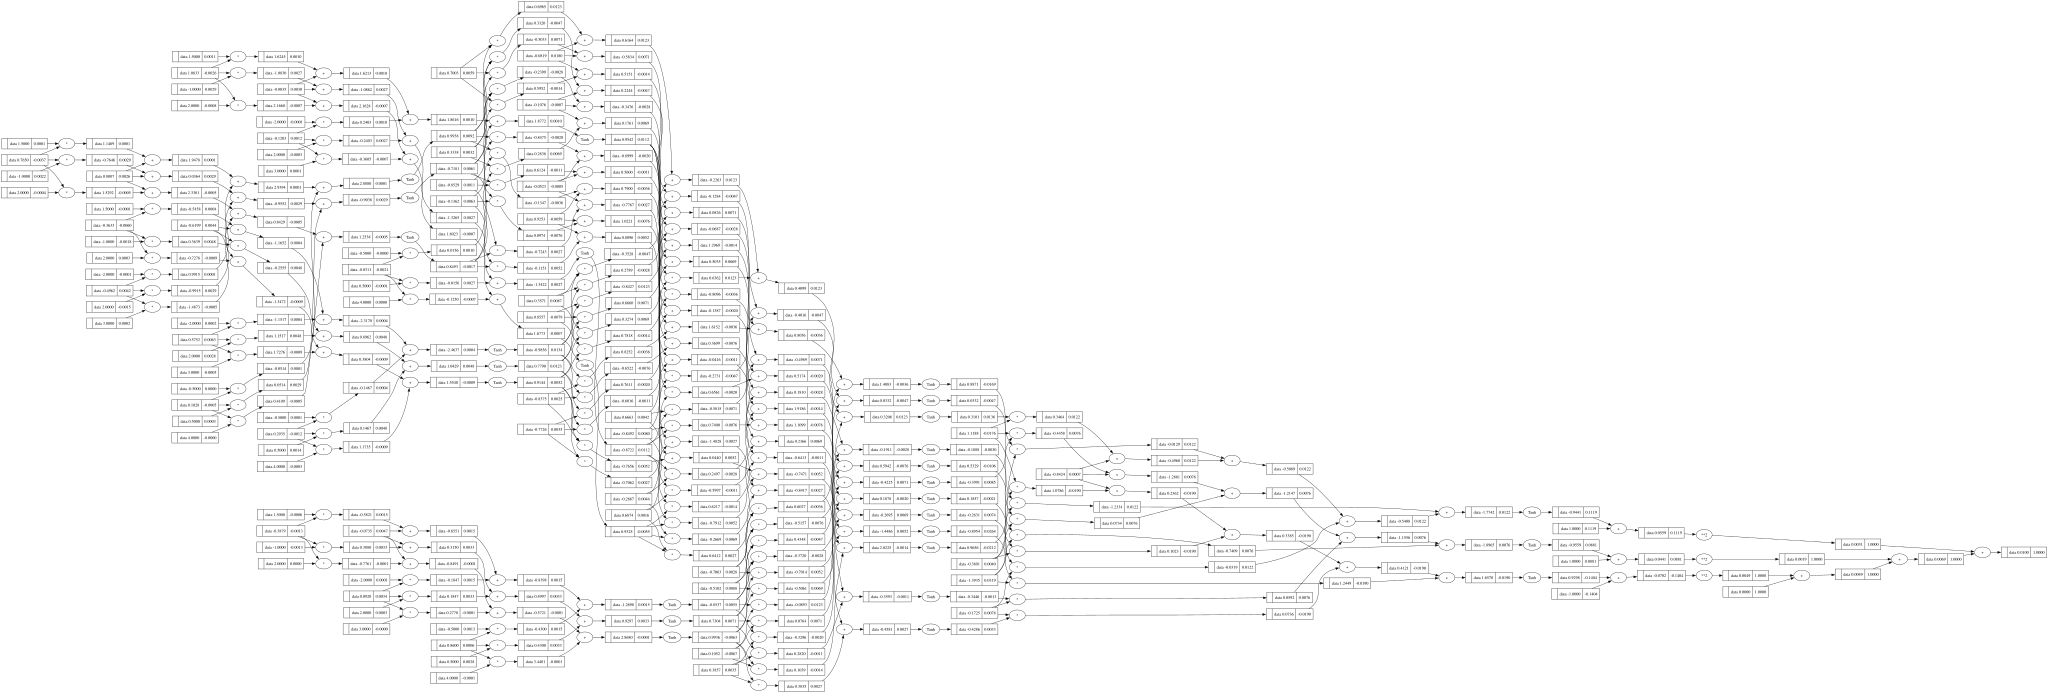

In [18]:
draw(loss)